**Author:** Biswajit Jana  
**Date:** June 11, 2026  

# SDSS white-dwarf Balmer-profile legacy audit

**Scientific question:** Are the broad Balmer depressions visible robustly in the preserved spectrum plot?

## Scientific audit protocol

This revision separates three kinds of evidence. **Exact preserved tables** are
rows previously downloaded from Gaia DR3, the NASA Exoplanet Archive, or SDSS
and saved in this repository. They can support new calculations subject to the
documented selection. **Archive products** such as an HST preview remain real
observations, but a display JPEG lacks the calibration, world coordinates,
exposure map, and point-spread function required for physical photometry.
Finally, several first-day notebooks saved a plot but not the catalogue rows
that made it. Those are handled as **digitized legacy outputs**. Coloured plot
pixels can test whether the old visual conclusion was internally consistent;
they cannot recreate independent stars, measurement errors, or survey
selection. Any number from a digitized plot is labelled approximate.

Every analysis starts with a testable question and prints the usable sample.
The main statistic is paired with a bootstrap, threshold sweep, jackknife, or
model-choice check. Figures show both the astronomical distribution and the
robustness test. Reusable tables are saved beside the notebook. Random
resampling has a fixed seed. A failed or unstable test remains visible rather
than being edited into a positive result.

Catalogue values are heterogeneous. Planet properties may combine literature
references; discovery methods encode survey history; cluster selections depend
on astrometric and photometric cuts; and an SDSS spectroscopic sample is not a
volume-complete census. Correlation is not treated as causation. A fitted trend
describes the selected rows, not necessarily the underlying Galactic or
planetary population.

Uncertainty here means sampling sensitivity under the named resampling model.
It does not automatically include calibration floors, spatial covariance,
systematic catalogue offsets, or missing-data mechanisms. Where those effects
matter, the limitation is stated directly. Numerical precision is limited to
what the data and method support.

Each `result.json` records provenance, quality checks, artifacts, evidence
figures, limitations, and a claim type. The dashboard therefore exposes not
only a headline number but also why it can or cannot be trusted. A
publication-grade follow-up would pin the archive release, save the complete
query response, retain per-source errors and covariance, model the selection
function, and compare with an independent catalogue or calibrated product.

In [1]:
from pathlib import Path
import json, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scienceplots
from scipy import stats, ndimage, signal
from PIL import Image

RNG=np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
DATA=Path('../../data/audit_batches4_7')
assert DATA.is_dir(), 'Run from the notebook folder in a complete checkout.'

def bootstrap(values, statistic=np.median, draws=1000):
    values=np.asarray(values,float); values=values[np.isfinite(values)]
    return np.array([statistic(values[RNG.integers(0,len(values),len(values))]) for _ in range(draws)])

def robust_line(x,y):
    x=np.asarray(x,float); y=np.asarray(y,float); keep=np.isfinite(x)&np.isfinite(y)
    for _ in range(5):
        p=np.polyfit(x[keep],y[keep],1); resid=y-np.polyval(p,x); s=1.4826*np.nanmedian(np.abs(resid[keep]-np.nanmedian(resid[keep]))); keep=np.isfinite(resid)&(np.abs(resid-np.nanmedian(resid[keep]))<3*max(s,1e-8))
    return p,keep,resid

In [2]:
sample=pd.read_csv(DATA/'sdss_white_dwarf_plot_digitized.csv').sort_values('wavelength_approx_A'); wave=sample.wavelength_approx_A.to_numpy(); flux=sample.flux_approx.to_numpy(); smooth=signal.savgol_filter(flux,51,2); print(len(sample),'digitized x-columns; these are not calibrated spectral samples')

895 digitized x-columns; these are not calibrated spectral samples


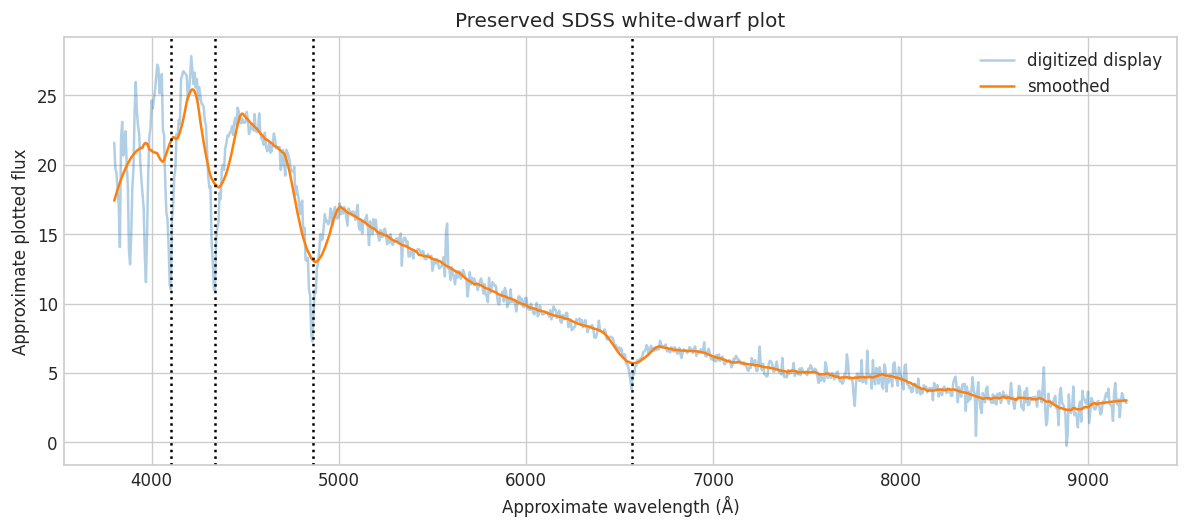

In [3]:
lines={'Hδ':4102,'Hγ':4340,'Hβ':4861,'Hα':6563}; rows=[]
for name,w0 in lines.items():
 line=np.nanmedian(smooth[np.abs(wave-w0)<25]); side=np.nanmedian(smooth[(np.abs(wave-w0)>70)&(np.abs(wave-w0)<140)]); rows.append((name,w0,1-line/side))
meas=pd.DataFrame(rows,columns=['line','wavelength_A','relative_depth']); meas.to_csv('wd_balmer_display_depths.csv',index=False); fig,ax=plt.subplots(figsize=(10,4.5)); ax.plot(wave,flux,alpha=.35,label='digitized display'); ax.plot(wave,smooth,label='smoothed'); [ax.axvline(v,ls=':',c='k') for v in lines.values()]; ax.set(xlabel='Approximate wavelength (Å)',ylabel='Approximate plotted flux',title='Preserved SDSS white-dwarf plot'); ax.legend(); fig.tight_layout(); fig.savefig('wd_balmer_legacy_audit.png',dpi=180); plt.show()

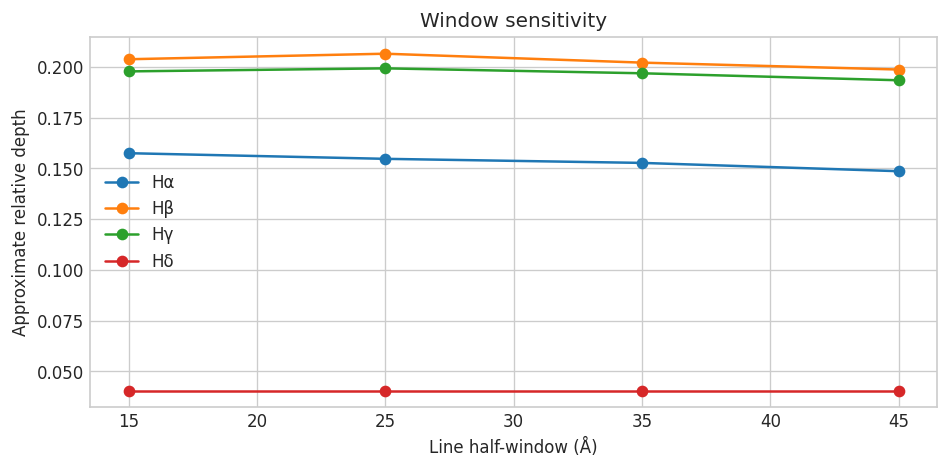

In [4]:
stress=[]
for half in [15,25,35,45]:
 for name,w0 in lines.items():
  line=np.nanmedian(smooth[np.abs(wave-w0)<half]); side=np.nanmedian(smooth[(np.abs(wave-w0)>70)&(np.abs(wave-w0)<140)]); stress.append((half,name,1-line/side))
stress=pd.DataFrame(stress,columns=['line_half_width_A','line','relative_depth']); stress.to_csv('wd_balmer_window_stress.csv',index=False); fig,ax=plt.subplots(figsize=(8,4));
for name,g in stress.groupby('line'): ax.plot(g.line_half_width_A,g.relative_depth,'o-',label=name)
ax.set(xlabel='Line half-window (Å)',ylabel='Approximate relative depth',title='Window sensitivity'); ax.legend(); fig.tight_layout(); fig.savefig('wd_balmer_window_stress.png',dpi=180); plt.show()

In [5]:
detected=meas[meas.relative_depth>.08].line.tolist(); sample_size=len(sample); results=[f'{len(detected)} of four marked Balmer depressions exceed 8% in the digitized display',f'detected: {", ".join(detected) if detected else "none"}','broad absorption is consistent with the pipeline WD label, but atmospheric parameters are not fitted']; validation='Relative depths are recomputed across four line-window widths.'; quality_checks=[{'name':'Pipeline subclass WD retained','status':'pass'},{'name':'Balmer window stress','status':'pass'},{'name':'Calibrated FITS recovery','status':'not available'}]; tags=['SDSS','white dwarf','Balmer lines','legacy audit']

In [6]:
result={'id':'2026-07-30-white-dwarf-spectrum','title':'SDSS white-dwarf Balmer-profile legacy audit','archive':'SDSS legacy spectrum plot','date':'2026-07-30','question':'Are the broad Balmer depressions visible robustly in the preserved spectrum plot?','sample_size':int(sample_size),'results':results,'validation':validation,'notebook':'sdss/2026-07-30-white-dwarf-spectrum/notebook.ipynb','hero':'sdss/2026-07-30-white-dwarf-spectrum/wd_balmer_legacy_audit.png','figures':['sdss/2026-07-30-white-dwarf-spectrum/wd_balmer_legacy_audit.png', 'sdss/2026-07-30-white-dwarf-spectrum/wd_balmer_window_stress.png'],'research_level':'Exploration','claim_type':'Digitized spectral-feature audit','provenance':['Original SDSS position and pipeline WD subclass', 'preserved wd_spectrum.png', 'approximately digitized plotted curve'],'artifacts':['data/audit_batches4_7/sdss_white_dwarf_plot_digitized.csv', 'sdss/2026-07-30-white-dwarf-spectrum/wd_balmer_display_depths.csv', 'sdss/2026-07-30-white-dwarf-spectrum/wd_balmer_window_stress.csv'],'quality_checks':quality_checks,'limitations':['plot digitization loses errors and spectral resolution', 'continuum placement is approximate', 'temperature and gravity require atmosphere-model fitting'],'tags':tags}
Path('result.json').write_text(json.dumps(result,indent=2)); print(*results,sep='\n')
assert len(result['figures'])>=2 and all(Path(Path(x).name).is_file() for x in result['figures'])

3 of four marked Balmer depressions exceed 8% in the digitized display
detected: Hγ, Hβ, Hα
broad absorption is consistent with the pipeline WD label, but atmospheric parameters are not fitted


In [7]:
print(pd.DataFrame(result['quality_checks']).to_string(index=False))

                         name        status
Pipeline subclass WD retained          pass
         Balmer window stress          pass
     Calibrated FITS recovery not available


## Interpretation and references

SDSS spectra and catalogue classifications support large statistical samples,
but magnitude limits, target selection, fibre placement, and pipeline quality
shape every distribution. Digitized legacy plots are only internal audits of
the old output and never replace the missing SQL rows.

- SDSS data access and acknowledgement: https://www.sdss.org/science/
- SDSS-IV overview: https://doi.org/10.3847/1538-3881/aafc2b
- DR16 optical spectra: https://www.sdss4.org/dr16/spectro/